# Lab-3 Descriptive Statistics and Visualization

1. Measures of Central Tendency (mean, median, mode)
2. Measures of Dispersion (variance, standard deviation, IQR)
3. Measures of Distribution Shape (skewness, kurtosis)
4. Data Visualizations (histograms, box plots, scatter plots)
5. Comparative Summary and Practical Guidance

The goal is not just to *compute* these statistics, but to build intuition for **when each one is
useful, what it tells you, and what it can hide.** Every concept is tied back to a concrete column
in our dataset so the numbers always mean something.

> **Audience:** this notebook assumes only basic familiarity with Python/pandas and no prior
> statistics background.

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# --- Core libraries used throughout the notebook ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Reproducibility: fixing the seed means everyone who runs this notebook gets identical numbers
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 42


In [3]:
# The four numeric features we will analyze throughout the notebook
FEATURES = ["exam_score", "monthly_allowance_inr", "quiz_score", "weekly_study_hours"]

from pathlib import Path
data_path = Path("student_survey_synthetic.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "student_survey_synthetic.csv was not found. Put the CSV in the same folder as this notebook "
        "and run this cell again."
    )
df = pd.read_csv(data_path)
print(f"Loaded {len(df)} rows from {data_path.resolve()}")


Loaded 160 rows from C:\Users\delli\dsLab\projects\Lab3\student_survey_synthetic.csv


**A quick sanity check before we analyze anything:** it's good practice to look at `.describe()`
and the data types before diving into specific statistics — this catches obvious data issues early
(wrong types, impossible values, missing data) and gives a first rough impression of scale and
spread for each column.

In [5]:
# Basic overview of the dataset
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (160, 6)

First 5 rows:


,student_id,exam_score,monthly_allowance_inr,quiz_score,weekly_study_hours,preferred_language
0,S001,68.85,4180.0,12.89,5.16,Java
1,S002,62.20,5110.0,14.60,6.09,Python
2,S003,74.49,2900.0,14.78,5.72,Python
3,S004,57.96,9290.0,10.74,5.34,Java
4,S005,73.60,2690.0,16.03,3.81,Java


In [6]:
# Summary statistics for the four numerical features
display(df[FEATURES].describe())

print("\nData types:")
print(df[FEATURES].dtypes)

print("\nMissing values:")
print(df[FEATURES].isnull().sum())

,exam_score,monthly_allowance_inr,quiz_score,weekly_study_hours
count,160.000,160.000,160.000,160.000
mean,71.931,4414.375,14.035,10.667
std,7.658,1909.942,2.764,7.105
min,53.120,1600.000,3.570,0.950
25%,66.330,3010.000,12.685,4.647
50%,72.150,4015.000,14.625,6.315
75%,77.220,5222.500,16.055,18.172
max,98.980,13790.000,18.670,24.140



Data types:
exam_score               float64
monthly_allowance_inr    float64
quiz_score               float64
weekly_study_hours       float64
dtype: object

Missing values:
exam_score               0
monthly_allowance_inr    0
quiz_score               0
weekly_study_hours       0
dtype: int64


In [4]:
# Confirm that all required columns are available and numeric
missing_columns = [col for col in FEATURES if col not in df.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

non_numeric = df[FEATURES].select_dtypes(exclude=np.number).columns.tolist()
if non_numeric:
    raise TypeError(f"These feature columns are not numeric: {non_numeric}")

print("Required columns found and numeric.")

Required columns found and numeric.


## 2. Measures of Central Tendency

Central tendency measures try to answer one question: **"what's a typical value in this data?"**
There are three common answers, and they are not interchangeable:

- **Mean** (average): sum of all values divided by how many there are. It uses every data point,
  which makes it efficient but also sensitive — one extreme value can pull it a long way.
- **Median**: the middle value when the data is sorted (or the average of the two middle values).
  It only cares about *position*, not magnitude, so extreme values barely move it.
- **Mode**: the most frequently occurring value. It's the only one of the three that makes sense
  for **categorical or discrete** data (you can't "average" favorite programming languages, but
  you can ask which one comes up most often).

**Rule of thumb:** use the mean when the data is roughly symmetric and outlier-free; switch to the
median when the data is skewed or contains outliers, because the median describes the "typical"
student far more honestly in those cases; use the mode when you care about the most common
category or the most frequent discrete value, not an averaged one.

In [5]:
# Calculate mean, median, and mode for each numerical feature

central_tendency = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Mode": df[FEATURES].mode().iloc[0]
})

display(central_tendency)

,Mean,Median,Mode
exam_score,71.931,72.150,66.33
monthly_allowance_inr,4414.375,4015.000,2630.00
quiz_score,14.035,14.625,9.27
weekly_study_hours,10.667,6.315,2.89


In [6]:
# Compare mean and median for each numerical feature

comparison = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Mean - Median": df[FEATURES].mean() - df[FEATURES].median()
})

display(comparison)

,Mean,Median,Mean - Median
exam_score,71.931,72.150,-0.219
monthly_allowance_inr,4414.375,4015.000,399.375
quiz_score,14.035,14.625,-0.590
weekly_study_hours,10.667,6.315,4.352


**Why is "mode" barely useful above?** Continuous measurements (like `exam_score`, rounded to two
decimal places) almost never repeat exactly, so the "most common value" is often just an
arbitrary tie-breaker rather than a meaningful typical value. Mode shines instead on **categorical
or discrete** data, where repeated exact values are the norm:

In [7]:
# Find the most common preferred programming language

language_mode = df["preferred_language"].mode()[0]

print("Most common preferred language:", language_mode)

Most common preferred language: Python


### When mean and median disagree: the outlier effect

The clearest way to see the mean's sensitivity to outliers is to watch what happens when we add a
single extreme value. Take `monthly_allowance_inr`, our right-skewed feature: suppose one student
receives a one-time scholarship payout of ₹150,000 that month. We'll add this one hypothetical
value to a **copy** of the data and compare.

In [8]:
# Demonstrate outlier sensitivity: mean vs. median on monthly_allowance_inr

original_mean = df["monthly_allowance_inr"].mean()
original_median = df["monthly_allowance_inr"].median()

df_outlier = df.copy()
df_outlier.loc[len(df_outlier), "monthly_allowance_inr"] = 150000

new_mean = df_outlier["monthly_allowance_inr"].mean()
new_median = df_outlier["monthly_allowance_inr"].median()

print("Before adding outlier:")
print("Mean:", original_mean)
print("Median:", original_median)

print("\nAfter adding ₹150,000 outlier:")
print("Mean:", new_mean)
print("Median:", new_median)


Before adding outlier:
Mean: 4414.375
Median: 4015.0

After adding ₹150,000 outlier:
Mean: 5318.633540372671
Median: 4030.0


In [9]:
#change caused by outlier
print("Change in mean:", new_mean - original_mean)
print("Change in median:", new_median - original_median)

Change in mean: 904.2585403726707
Change in median: 15.0


In [10]:
# Calculate Q1, Q3, and IQR for each numerical feature

q1 = df[FEATURES].quantile(0.25)
q3 = df[FEATURES].quantile(0.75)

iqr = q3 - q1

iqr_table = pd.DataFrame({
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr
})

display(iqr_table)

,Q1,Q3,IQR
exam_score,66.330,77.220,10.890
monthly_allowance_inr,3010.000,5222.500,2212.500
quiz_score,12.685,16.055,3.370
weekly_study_hours,4.647,18.172,13.525


**Interpretation:** a single unusual value dragged the mean sharply upward, but the median barely
moved, because the median only depends on which value sits in the middle position — and adding one
extra point far out in the tail doesn't change *what's in the middle*. This is exactly why the
median is described as **robust** to outliers, and why right-skewed data (like income, prices, or
allowances) is usually summarized with a median rather than a mean in real reporting.

Note that `monthly_allowance_inr` and `quiz_score` already show mean and median pulling apart even
*without* an artificial outlier — that's the natural fingerprint of skewness, which we'll quantify
precisely in Section 4.

In [11]:
# Calculate outlier bounds using the 1.5 × IQR rule

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_bounds = pd.DataFrame({
    "Q1": q1,
    "Q3": q3,
    "IQR": iqr,
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound
})

display(outlier_bounds)

,Q1,Q3,IQR,Lower Bound,Upper Bound
exam_score,66.330,77.220,10.890,49.995,93.555
monthly_allowance_inr,3010.000,5222.500,2212.500,-308.750,8541.250
quiz_score,12.685,16.055,3.370,7.630,21.110
weekly_study_hours,4.647,18.172,13.525,-15.640,38.460


In [12]:
# Identify and count outliers using the 1.5 × IQR rule

for feature in FEATURES:
    outliers = df[
        (df[feature] < lower_bound[feature]) |
        (df[feature] > upper_bound[feature])
    ][feature]

    print(f"\n{feature}")
    print("Number of outliers:", len(outliers))
    print("Outlier values:")
    print(outliers.values)


exam_score
Number of outliers: 1
Outlier values:
[98.98]

monthly_allowance_inr
Number of outliers: 6
Outlier values:
[ 9290.  9520.  9660.  9180.  8830. 13790.]

quiz_score
Number of outliers: 5
Outlier values:
[3.57 6.92 7.62 7.42 4.12]

weekly_study_hours
Number of outliers: 0
Outlier values:
[]


## 3. Measures of Dispersion

Central tendency tells us where the "middle" of the data is, but says nothing about how **spread
out** the values are around that middle. Two features can have the same mean and look completely
different. Three common measures of spread:

- **Variance**: the average of the squared deviations from the mean. Squaring guarantees a
  non-negative measure and gives larger deviations disproportionately more weight, but it also
  changes the *units* (e.g., "score points squared"), which makes variance hard to interpret
  directly.
- **Standard deviation**: simply the square root of the variance. This brings the units back to
  the original scale (e.g., "score points"), which is why standard deviation — not variance — is
  the number people usually quote and interpret ("scores typically fall within about 8 points of
  the mean").
- **Interquartile range (IQR)**: the range covered by the middle 50% of the data (`Q3 - Q1`). Like
  the median, it ignores the extreme tails entirely, so it is **robust to outliers** in the same
  way the median is — a useful pairing when your central tendency measure is also the median.

**When to prefer which:** use standard deviation alongside the mean for roughly symmetric,
outlier-free data (it's the natural companion in that setting); use IQR alongside the median when
the data is skewed or has outliers, since both are computed only from ranked positions and stay
stable even if the tails stretch further.

### Manual calculation, step by step

Before relying on built-in functions, let's calculate the variance and standard deviation of
`exam_score` by hand, following the definition directly:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

(We divide by `n - 1`, not `n` — this is the *sample* variance formula, which corrects a slight
downward bias that occurs when the mean itself is estimated from the same sample. `pandas` and
`numpy`'s `ddof=1` option use this convention by default in `.var()`/`.std()`.)

In [13]:
# --- Manual, step-by-step variance & standard deviation for exam_score ---
x = df["exam_score"].values
n_obs = len(x)
    
# Step 1: Calculate the mean
mean_x = sum(x) / n_obs
print("Mean:", mean_x)

# Step 2: Calculate deviations from the mean
deviations = x - mean_x
print("\nDeviations from mean:")
print(deviations)

# Step 3: Square the deviations
squared_deviations = deviations ** 2
print("\nSquared deviations:")
print(squared_deviations)

# Step 4: Sum the squared deviations
sum_squared_deviations = sum(squared_deviations)
print("\nSum of squared deviations:", sum_squared_deviations)

# Step 5: Calculate sample variance
manual_variance = sum_squared_deviations / (n_obs - 1)
print("\nManual sample variance:", manual_variance)

# Step 6: Calculate standard deviation
manual_std = manual_variance ** 0.5
print("Manual standard deviation:", manual_std)

# Verify using NumPy
numpy_variance = np.var(x, ddof=1)
numpy_std = np.std(x, ddof=1)

print("\nNumPy variance:", numpy_variance)
print("NumPy standard deviation:", numpy_std)

print("\nVariance matches:", np.isclose(manual_variance, numpy_variance))
print("Standard deviation matches:", np.isclose(manual_std, numpy_std))

Mean: 71.93068750000002

Deviations from mean:
[ -3.0806875  -9.7306875   2.5593125 -13.9706875   1.6693125   4.9993125
   4.7093125  14.4893125   6.3793125  11.3893125  -9.8206875   4.3493125
   3.6493125   7.1793125   5.4093125  -1.7606875   3.7093125  -1.8206875
   5.1093125   9.0593125  -5.8706875   1.9193125  13.2193125  -0.1206875
   3.4693125  -1.0006875   2.9393125 -10.5406875   7.1993125  -5.6006875
   4.1693125  12.1093125 -10.3706875  -2.7706875  -0.4006875  -7.7006875
  -4.9106875  16.3593125   0.4393125   6.0493125   0.4693125  -8.9306875
   7.6193125  -7.6806875   2.1993125  -3.8806875   6.2693125   7.8193125
  -2.9606875   0.8193125  11.7593125   5.2493125  -0.1106875 -14.2206875
  -1.5506875  14.0993125  -8.6106875   0.4593125   4.2293125 -10.7506875
  -2.6306875  -5.4306875 -11.5206875   9.1593125   1.0293125  11.1093125
   6.1993125   1.5593125   6.8393125  -1.7206875  -5.9606875  11.1293125
  -4.4306875  13.4793125  -4.7206875  -2.9106875   4.2293125   0.3293125
 -15

## IQR — Interquartile Range

IQR measures the spread of the middle 50% of the data.

$$ \boxed{IQR=Q_3-Q_1} $$

where:

Q1= 25th percentile
Q2= 50th percentile (median)
Q3 = 75th percentile

**Reading this table:** notice `monthly_allowance_inr` has a huge variance/std simply because it is
measured in rupees on a much larger numeric scale than, say, `quiz_score` out of 20 — variance and
standard deviation are **not comparable across features with different units or scales** without
standardizing first (we'll do this in Section 5 for the box plot comparison). IQR has the same
scale issue, but within a single skewed feature it remains a more trustworthy "typical spread"
than variance/std, since it isn't inflated by the long tail the way squared deviations are.

## 4. Measures of Distribution Shape

Central tendency and dispersion tell us "where" and "how spread out," but not "what shape." Two
features can share the same mean and standard deviation while looking completely different when
plotted. Skewness and kurtosis quantify shape numerically.

- **Skewness** measures asymmetry — which side has the longer tail.
  - Skewness **≈ 0**: roughly symmetric (like a normal distribution).
  - Skewness **> 0** (right/positive skew): a long tail stretches to the **right**; typically
    `mean > median` because a few large values pull the mean upward.
  - Skewness **< 0** (left/negative skew): a long tail stretches to the **left**; typically
    `mean < median` because a few small values pull the mean downward.

- **Kurtosis** (we use *excess* kurtosis, i.e. relative to the normal distribution's value of 0)
  measures tail heaviness and peak sharpness.
  - Excess kurtosis **≈ 0** (mesokurtic): tails behave like a normal distribution.
  - Excess kurtosis **> 0** (leptokurtic): heavier tails and/or a sharper peak than normal — more
    extreme outliers than you'd expect from a normal curve.
  - Excess kurtosis **< 0** (platykurtic): lighter tails and a flatter, more spread-out peak — data
    is more "spread across the middle" than a normal curve, which is exactly what a **bimodal**
    distribution tends to look like (probability mass pulled away from the center into two humps).

Together, skewness and kurtosis are a quick numerical check for **departures from normality** —
useful because many classical statistical methods (t-tests, linear regression, etc.) assume
approximately normal data.

**Tying this back to how we designed the data:**

- `exam_score` was built to be approximately normal, and indeed its skewness and excess kurtosis
  both sit close to 0.
- `monthly_allowance_inr` was built right-skewed (lognormal), which shows up as clearly positive
  skewness — consistent with the mean sitting above the median we saw in Section 2.
- `quiz_score` was built left-skewed (a ceiling effect where most students score high), and its
  skewness comes out negative, matching `mean < median` from Section 2.
- `weekly_study_hours` was built as a **mixture of two groups** (bimodal). Its skewness is modest,
  but notice the **negative excess kurtosis** — this is the classic numeric signature of a
  flatter-than-normal, two-humped shape. This is also a great cautionary example: **skewness and
  kurtosis alone cannot conclusively prove a distribution is bimodal** — a low/negative kurtosis is
  a hint, but only a histogram (Section 5) actually *shows* the two humps directly. Summary
  statistics can point you in the right direction, but they can also hide structure that only a
  picture reveals.

## Distribution of exam_score


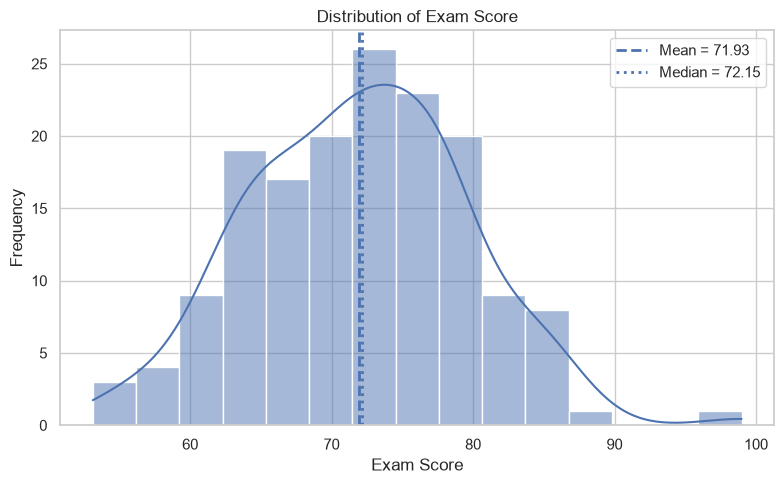

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="exam_score",
    kde=True,
    bins=15
)

mean_value = df["exam_score"].mean()
median_value = df["exam_score"].median()

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

Interpretation: The exam score distribution is approximately normal and symmetric, with most scores concentrated around the centre. The skewness is close to 0, indicating little asymmetry. The excess kurtosis is also close to 0, indicating that the tails are similar to those of a normal distribution. Therefore, the distribution is approximately mesokurtic.

## Distribution of monthly_allowance_inr

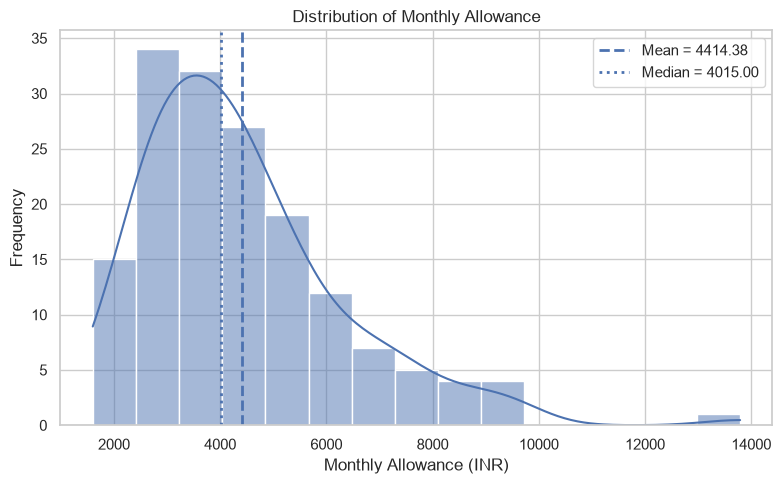

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="monthly_allowance_inr",
    kde=True,
    bins=15
)

mean_value = df["monthly_allowance_inr"].mean()
median_value = df["monthly_allowance_inr"].median()

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

plt.title("Distribution of Monthly Allowance")
plt.xlabel("Monthly Allowance (INR)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

Interpretation: The monthly allowance distribution is right-skewed, with most students having lower allowances and a smaller number having much higher allowances. This creates a long tail towards the right and causes the mean to be greater than the median. The positive skewness confirms the right-skewed nature of the distribution. Its positive excess kurtosis indicates leptokurtosis, meaning the distribution has heavier tails and potentially more extreme values than a normal distribution.

## Distribution of quiz_score

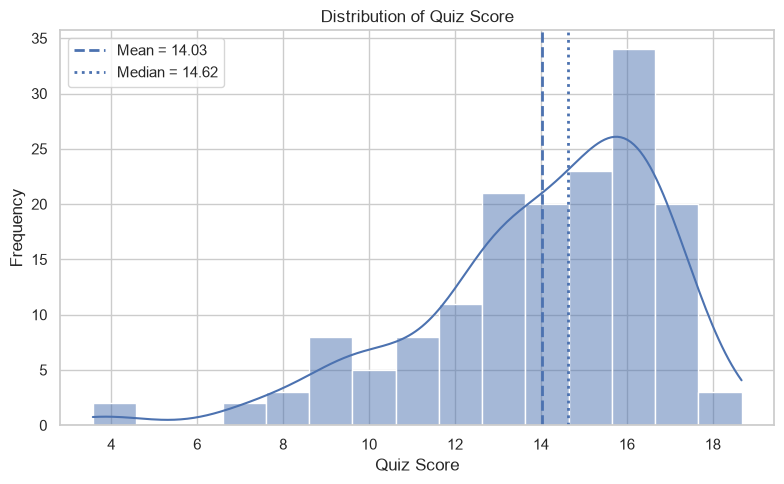

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="quiz_score",
    kde=True,
    bins=15
)

mean_value = df["quiz_score"].mean()
median_value = df["quiz_score"].median()

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

plt.title("Distribution of Quiz Score")
plt.xlabel("Quiz Score")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

Interpretation: The quiz score distribution is left-skewed, with most students scoring towards the higher end and a tail extending towards lower scores. The negative skewness confirms this left-skewed pattern and causes the mean to be lower than the median. The distribution's excess kurtosis indicates how its tails compare with a normal distribution. This left skew is mainly explained by the ceiling effect described in the notebook.

## Distribution of weekly_study_hours

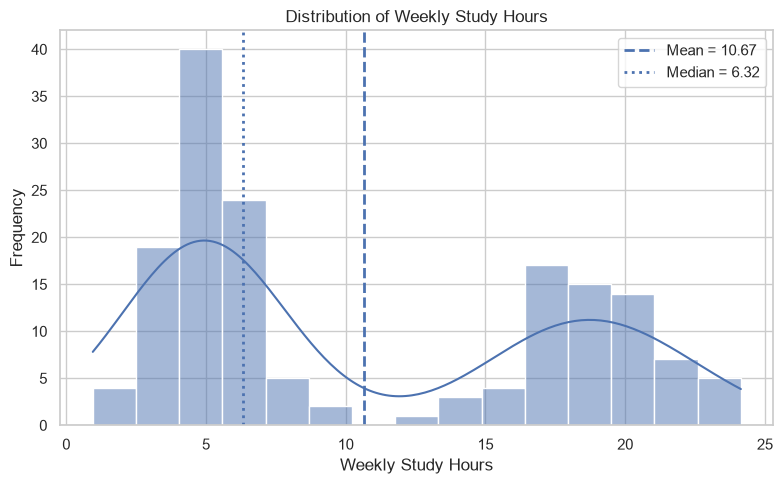

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="weekly_study_hours",
    kde=True,
    bins=15
)

mean_value = df["weekly_study_hours"].mean()
median_value = df["weekly_study_hours"].median()

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

plt.title("Distribution of Weekly Study Hours")
plt.xlabel("Weekly Study Hours")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

Interpretation: The weekly study hours distribution is bimodal, showing two distinct peaks that represent two different groups of students. Its skewness is relatively modest because the two groups balance each other to some extent. The negative excess kurtosis indicates a platykurtic distribution, meaning it is flatter and has lighter tails than a normal distribution. The negative kurtosis is consistent with the two-humped shape, although kurtosis alone cannot prove that a distribution is bimodal.

## 5. Data Visualizations

Numbers alone can mislead — this is sometimes called "Anscombe's quartet problem," where wildly
different-looking datasets share identical means, variances, and correlations. Visualizations let
us confirm (or challenge) what the summary statistics suggested, and they reveal structure — like
the bimodal split in `weekly_study_hours` — that a single number cannot.

**Insight this gives that raw numbers can't:** you can *see* exactly how mean and median relate to
each tail — for `monthly_allowance_inr`, the mean is visibly pulled right of the median by the long
tail of high earners; for `quiz_score`, it's pulled left. For `weekly_study_hours`, the mean and
median both land in the empty "valley" between the two humps — a value that hardly any actual
student has. This is the single clearest illustration in the whole notebook of why a central
tendency number can be actively misleading without a picture to check it against.

### 5.1 Box plots

A box plot summarizes five numbers at once: the minimum (within 1.5×IQR of Q1), Q1 (25th
percentile), the median (Q2, 50th percentile), Q3 (75th percentile), and the maximum (within
1.5×IQR of Q3) — with any points beyond that range flagged as individual outlier dots. It's a
compact way to compare spread and skewness *across several features at once*, which a table of
numbers makes you compare column by column.

Because our four features live on very different scales (₹ vs. hours vs. a 0-100 score vs. a 0-20
score), we standardize each feature to a common z-score scale (mean 0, standard deviation 1) purely
for this side-by-side comparison — standardizing preserves each feature's *shape* while making the
spreads visually comparable.

**Insight this gives that raw numbers can't:** side-by-side boxes make skewness visible as an
*asymmetric* box — notice how `monthly_allowance_inr`'s box and whisker stretch much further above
the median than below it (right-skew), the mirror image for `quiz_score`, and how
`monthly_allowance_inr` shows individual outlier dots above the top whisker, flagging the same
"a few students earn a lot more" pattern we quantified with skewness in Section 4 — but now you can
see exactly how many outliers there are and how extreme each one is, which a single skewness number
cannot show.

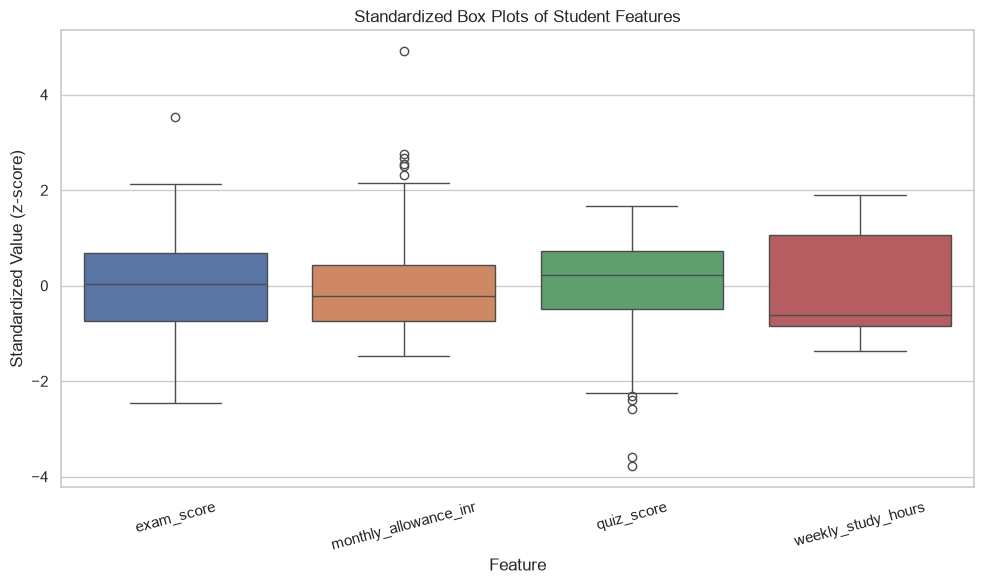

In [19]:
# Standardize the numerical features using z-scores

z_scores = (
    df[FEATURES] - df[FEATURES].mean()
) / df[FEATURES].std()

plt.figure(figsize=(10, 6))

sns.boxplot(data=z_scores)

plt.title("Standardized Box Plots of Student Features")
plt.xlabel("Feature")
plt.ylabel("Standardized Value (z-score)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### 5.2 Scatter plots

Scatter plots reveal **relationships between two features** — something no single-feature
statistic (mean, std, skewness, etc.) can show at all, no matter how many of them you compute. We
show one pair with a clear relationship and one pair with essentially none, so you can compare what
"a real pattern" looks like against "no pattern" side by side.

## quiz_score vs exam_score

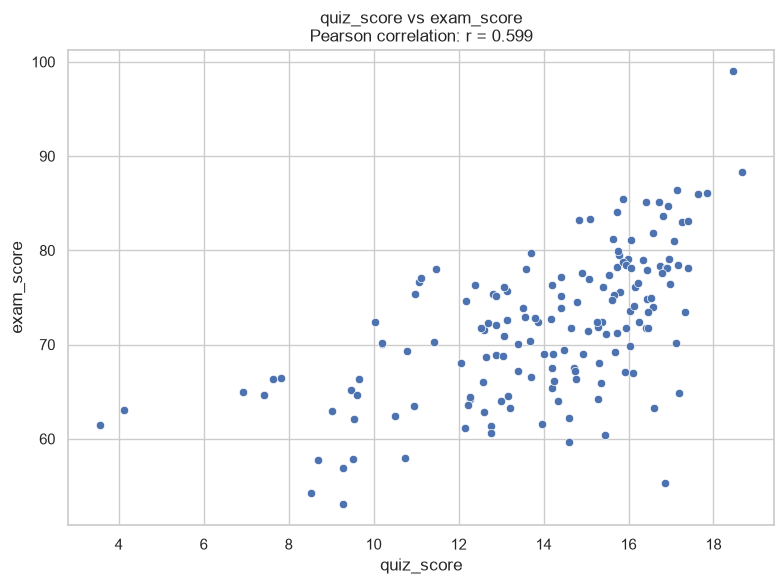

Pearson correlation between quiz_score and exam_score: 0.599


In [20]:
x = "quiz_score"
y = "exam_score"

r = df[x].corr(df[y])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=x,
    y=y
)

plt.title(f"{x} vs {y}\nPearson correlation: r = {r:.3f}")
plt.xlabel(x)
plt.ylabel(y)

plt.tight_layout()
plt.show()

print(f"Pearson correlation between {x} and {y}: {r:.3f}")

## quiz_score vs monthly_allowance_inr

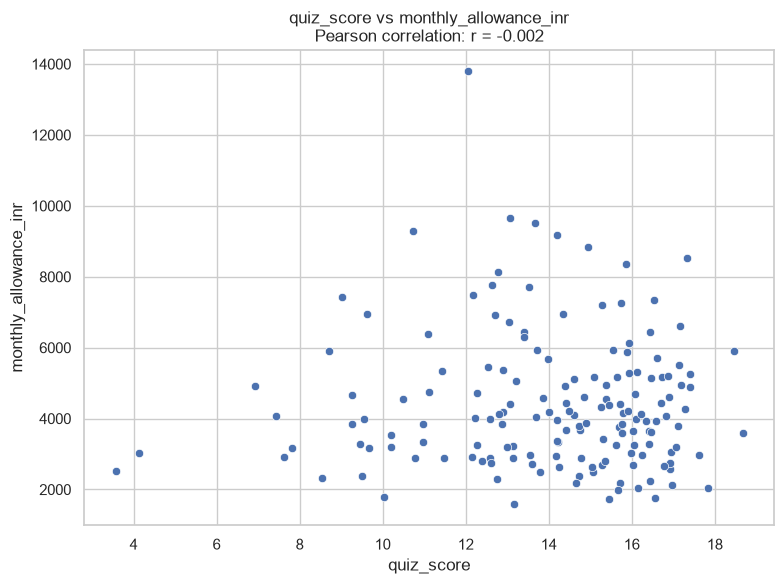

Pearson correlation between quiz_score and monthly_allowance_inr: -0.002


In [21]:
x = "quiz_score"
y = "monthly_allowance_inr"

r = df[x].corr(df[y])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=x,
    y=y
)

plt.title(f"{x} vs {y}\nPearson correlation: r = {r:.3f}")
plt.xlabel(x)
plt.ylabel(y)

plt.tight_layout()
plt.show()

print(f"Pearson correlation between {x} and {y}: {r:.3f}")

### Pearson Correlation Coefficient

The **Pearson correlation coefficient** measures the strength and direction of the linear relationship between two numerical variables, $X$ and $Y$.

The formula is:

$$
\boxed{
r =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{
\sum_{i=1}^{n}(x_i-\bar{x})^2
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
}
}
$$

where:

- $r$ = Pearson correlation coefficient
- $x_i$ = individual observation of variable $X$
- $y_i$ = individual observation of variable $Y$
- $\bar{x}$ = mean of variable $X$
- $\bar{y}$ = mean of variable $Y$
- $n$ = number of observations

The Pearson correlation coefficient always lies between:

$$
\boxed{-1 \leq r \leq +1}
$$

### Interpretation of Correlation Values

| Correlation ($r$) | Interpretation |
|---:|---|
| $+1.00$ | Perfect positive correlation |
| $+0.70$ to $+0.99$ | Strong positive correlation |
| $+0.30$ to $+0.69$ | Moderate positive correlation |
| $-0.29$ to $+0.29$ | Weak or little linear correlation |
| $-0.30$ to $-0.69$ | Moderate negative correlation |
| $-0.70$ to $-0.99$ | Strong negative correlation |
| $-1.00$ | Perfect negative correlation |

### Direction of Correlation

**Positive correlation:**

$$
X\uparrow \Rightarrow Y\uparrow
$$

As $X$ increases, $Y$ tends to increase.

**Negative correlation:**

$$
X\uparrow \Rightarrow Y\downarrow
$$

As $X$ increases, $Y$ tends to decrease.

**No linear correlation:**

$$
r\approx0
$$

There is little or no **linear** relationship between $X$ and $Y$.

### Example

Suppose:

$$
r(\text{quiz score},\text{exam score})=0.82
$$

This indicates a **strong positive linear relationship** between quiz score and exam score. Students with higher quiz scores tend to have higher exam scores.

### Important Points

1. **Correlation does not imply causation.**  
   A strong correlation does not prove that one variable causes changes in another.

2. **Pearson correlation measures linear relationships.**  
   A correlation close to zero does not necessarily mean that there is no relationship. The variables may have a strong nonlinear relationship.

3. **Outliers can affect Pearson correlation.**  
   Therefore, a scatter plot should be examined before interpreting the correlation coefficient.

4. **Only appropriate numerical variables should be included.**  
   Identifier columns such as `student_id` and categorical variables such as `preferred_language` should not be directly included in a Pearson correlation matrix.

### Key Takeaway

> **A correlation heatmap provides a quick visual summary of the direction and strength of linear relationships among numerical variables. Pearson correlation quantifies this relationship on a scale from $-1$ to $+1$.**

In [23]:
# Correlation matrix for numeric features
correlation_matrix = df[FEATURES].corr()
display(correlation_matrix)

,exam_score,monthly_allowance_inr,quiz_score,weekly_study_hours
exam_score,1.000,-0.012,0.599,0.102
monthly_allowance_inr,-0.012,1.000,-0.002,-0.026
quiz_score,0.599,-0.002,1.000,0.044
weekly_study_hours,0.102,-0.026,0.044,1.000


## Pearson Correlation  quiz_score vs exam_score

In [24]:
r = df["quiz_score"].corr(df["exam_score"])

print("Pearson correlation coefficient:")
print(f"r = {r:.3f}")

Pearson correlation coefficient:
r = 0.599


## Pearson Correlation  quiz_score vs monthly_allowance_inr

In [25]:
r = df["quiz_score"].corr(df["monthly_allowance_inr"])

print("Pearson correlation coefficient:")
print(f"r = {r:.3f}")

Pearson correlation coefficient:
r = -0.002


## Correlation Heatmap

A **correlation heatmap** is a graphical representation of the correlation matrix. It uses colors and numerical values to show the **strength and direction of the linear relationship** between pairs of numerical variables.


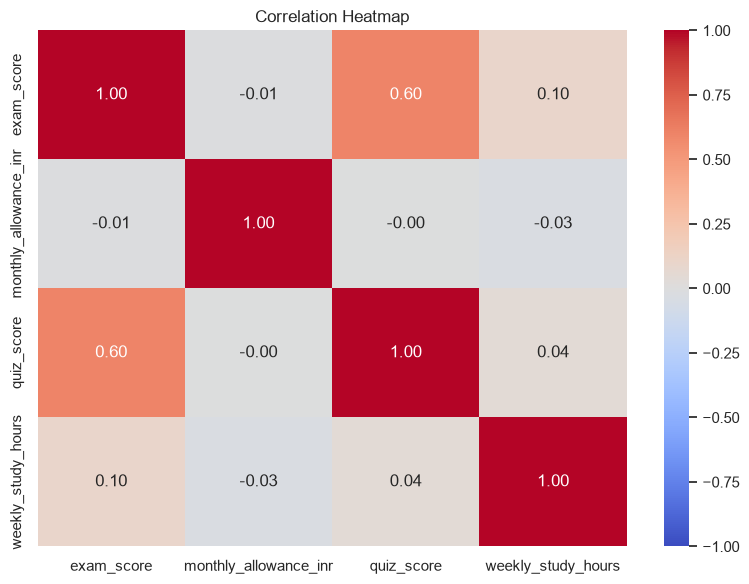

In [26]:
correlation_matrix = df[FEATURES].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

**Inference:** The correlation heatmap provides an overall view of the linear relationships between the numerical features. A strong positive correlation indicates that two variables tend to increase together, while a negative correlation indicates that one tends to decrease as the other increases. Values close to zero indicate little or no linear relationship. The heatmap therefore makes it easy to identify which features are strongly related and which are relatively independent. However, correlation measures association rather than causation, and a correlation close to zero does not rule out a nonlinear relationship.

## CONCLUSION

This experiment demonstrated the use of descriptive statistics and data visualizations to understand the characteristics and relationships within a student dataset. Measures of central tendency such as the mean, median, and mode were used to describe the typical values of the numerical and categorical features. Measures of dispersion, including variance, standard deviation, and interquartile range, were used to examine the spread of the data and identify potential outliers.

The distribution analysis showed that the features can have substantially different shapes. exam_score was approximately normally distributed, monthly_allowance_inr was right-skewed, quiz_score was left-skewed due to a ceiling effect, and weekly_study_hours displayed a bimodal pattern. Skewness and excess kurtosis provided numerical evidence about asymmetry and tail behaviour, while the histograms provided visual confirmation of the underlying distributions.

The experiment also demonstrated the effect of outliers on statistical measures. An extreme value had a much greater effect on the mean than on the median, illustrating why the median and IQR are often preferable for skewed data or data containing outliers. Finally, scatter plots, Pearson correlation coefficients, and the correlation heatmap were used to investigate relationships between numerical variables. Overall, the experiment showed that statistical measures and visualizations should be used together: numerical summaries describe the data efficiently, while visualizations reveal distributional patterns, outliers, and relationships that individual statistics may not capture.